# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

<center>
<img src="figures\opdracht_1.jpeg" width="1000">
</center>

opgaven c staat bij de foto bij opdracht 2

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

<center>
<img src="figures\voldoen_voorwaarden.jpeg" width="1000">
</center>


Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

<center>
<img src="figures\opdracht_3.jpeg" width="1000">
</center>

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

<center>
<img src="figures\tekening-1,2.jpeg" width="1000">
</center>
<center>
<img src="figures\tekening_3,4.jpeg" width="1000">
</center>
<center>
<img src="figures\tekening_5.jpeg" width="1000">
</center>

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

<center>
<img src="figures\opdracht_5.jpeg" width="1000">
</center>
<center>
<img src="figures\extra_criterium.jpeg" width="1000">
</center>

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

Plaats in deze cel een png met jullie eventuele analytische uitwerkingen.

In [2]:
#Ik heb de analytische uitwerking in code geschreven  i.p.v op papier uitgewerkt

#We zoeken een functie die de maximale draadlengte uitrekent met behulp van de wet van Ohm
#Hoe lang mag de koperdraad van je spoel maximaal zijn, zodat de stroom niet groter wordt dan wat de spanningsbron kan leveren?

#De wet van Ohm in relatie tot de maximale stroom die een bron kan leveren

#Hoe langer de draad hoe groter de weerstand
#Bij een bron met een maximale stroom die die mag leveren hoort een weerstand die niet kleiner mag zijn dan een bepaalde waarde:
#De waarden hieronder zijn voorbeelden 

V = 20 #V
I = 2 #A

minimale_weerstand = V/I

#Uit deze minimale weerstand wordt de maximale draadlengte verkregen
#Met de weerstand van een draad:

rho = 1.68e-8    #soortelijke weerstand
L =   1          #draadlengte
A =   1          #doorsnede draad

R = rho* (L/A)
L = (R*A)/rho
L_max = minimale_weerstand * (A/rho)        #invullen R = V/I (minimale weerstand)


In [3]:
#Nu definiëren we de formule voor maximale draadlengte en berekenen die voor de twee toepassingen en de gegeven deuractuator

def max_draadlengte(V, I, d):
    rho = 1.68e-8
    R = V/I
    A = np.pi* (d/2)**2
    L = (R * A) / rho
    return L


#Toepassing 1
#Hondenvoerder

V_hond = 20 #V
I_hond = 2 #A
d_hond = 0.2e-3 #diameter koperdraad rondom de spoel (m), met bron de telefoonoplader

print("De maximale draadlengte voor de spoel in de hondenvoeractuator is %.1f m" % max_draadlengte(V_hond, I_hond, d_hond))

#Toepassing 2
#Waterklep wasmachine

V_was = 20 #V
I_was = 2 #A
d_was = 0.2e-3 #diameter koperdraad rondom de spoel (m), met bron de telefoonoplader

print("De maximale draadlengte voor de spoel in de waterklepactuator is ook %.1f m" % max_draadlengte(V_was, I_was, d_was))

#Deuractuator

V_deur = 9
I_deur = 0.5
d_deur = 0.1e-3 #diameter koperdraad rondom de spoel (m), met bron de 9V batterij


print("De maximale draadlengte voor de spoel in de deuractuator is %.1f m" % max_draadlengte(V_deur, I_deur, d_deur))

De maximale draadlengte voor de spoel in de hondenvoeractuator is 18.7 m
De maximale draadlengte voor de spoel in de waterklepactuator is ook 18.7 m
De maximale draadlengte voor de spoel in de deuractuator is 8.4 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

<center>
<img src="figures\opdracht_7.jpg" width="1000">
</center>

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

Plaats hier een png met jullie eventuele analytische afleiding.

In [4]:
#We zoeken een python functie die voor een gekozen actuator checkt:

#1. Hoeveel windingen heb ik minimaal nodig voor deze actuator (F = mg, zie de afbeelding hierboven bij opgave 7 met de afleiding van die formule)
#2. Hoeveel windingen er maximaal fysiek in passen
#3. Is het ontwerp realistisch


In [5]:
### BEGIN SOLUTION

#L_s lengte van de solenoïde (lengte spoel) (m)
#z_p hoe ver de plunjer in de spoel zit (m)
#r_s de straal van de solenoïde (hoe groot is de spoel) (m)
#I stroom door de spoel (A)
#mu_r relatieve permeabiliteit van het materiaal (hoe magnetisch veld geleid)
#d draadikte (m)

def aantal_wikkelingen(F_min, L_s, r_s, I, z_p, mu_r, d, max_draadlengte):

    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.

    mu_0 = (4* np.pi)*(10**-7) #permeabiliteit van lucht
    
    #minimum aantal windingen
    N_min = np.sqrt((2 * F_min * ((L_s - z_p) + z_p / mu_r)**2) / (mu_0 * np.pi * r_s**2 * I**2 * (1 - 1/mu_r)))

    #maximum aantal windingen door de lengte van de spoel
    N_max_1 = L_s / d

    #maximum aantal windingen door de draadlengte van de spoel
    #Totale draad / lengte per winding = aantal windingen
    #Lengte per winding (2*pi*r_s)

    N_max_2 = max_draadlengte / (2 * np.pi * r_s)

    #Juiste maximum nemen (Er passen N_max_1 windingen in, maar het ligt eraan hoeveel we hebben, dus we zoeken de kleinste van de twee mogelijk aantal maximum windingen)
    N_max = min(N_max_1, N_max_2)

    if N_min > N_max: ## Als het ontwerp niet mogelijk is.
        print("Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.")
        N_min = np.nan
        N_max = np.nan
        N_max = min(N_max_1,N_max_2)
    return N_min, N_max


print(aantal_wikkelingen(0.001, 0.05, 0.01, 2, 0.02, 1000, 0.0005, 10))

(np.float64(33.80127462838283), 100.0)


Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

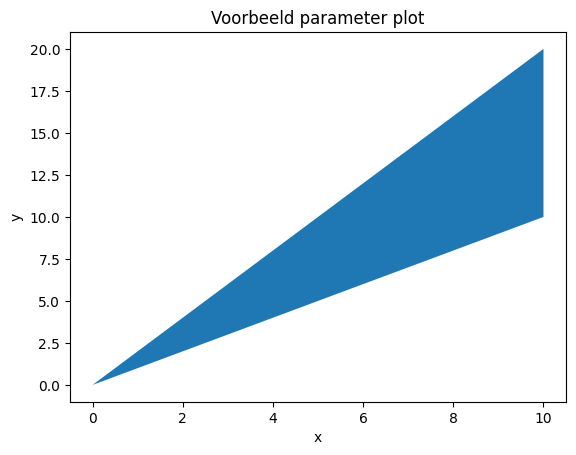

In [6]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



In [7]:
#alle waarden die we nodig hebben

Ls_waarden = np.linspace(0.001, 1, 50)

#parameters

#stroombron (I)(A)
I_deur = 0.5
I_hond = 2
I_was = 2

#diameter (d)(m)
d_deur = 2e-4
d_hond = 2e-4
d_was = 1e-4

#straal actuator (r_s) (m)
r_s_deur = 0.01 
r_s_hond = 0.01
r_s_was = 0.012

#F_min
F_hondenklep = 0.005 #N
F_waterdruk = 0.005 #N
F_deur = 0.00040 #N

#maximale draadlengte (m)
ld_deur = max_draadlengte(V_deur, I_deur, d_deur)
ld_hond = max_draadlengte(V_hond, I_hond, d_hond)
ld_was = max_draadlengte(V_was, I_was, d_was)



Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter dan het maximum aantal windingen.
Foutmelding: het minimum aantal windingen is groter da

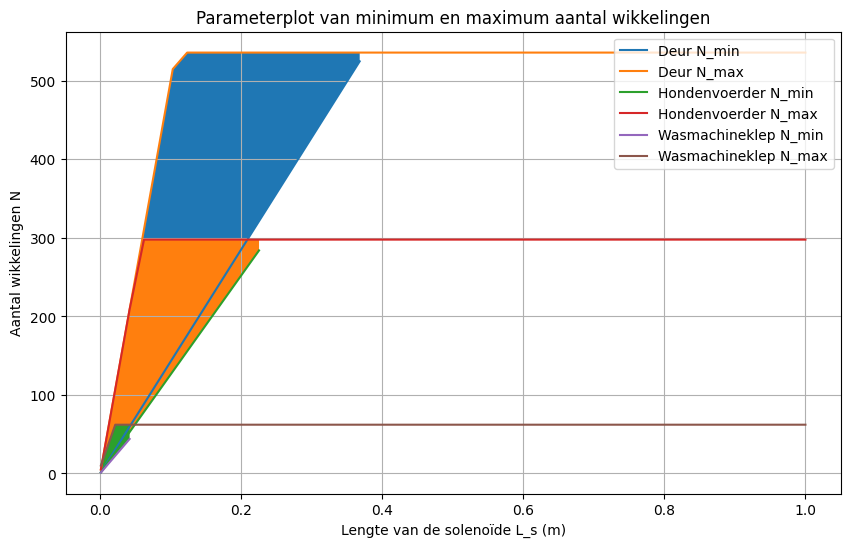

In [8]:
#plotten van de parameterplot

#de permeabiliteit (mu_r) nemen we voor ijzer
mu_r = 1000 #ijzer

#we zoeken nu naar het minimum en maximum aantal windingen van een solenoïde (dat afhangt van de lengte (L_s) van de spoel, en hoever het magnetische materiaal erin zit (z_p))

#lege arrays
Nmin_deur = []
Nmax_deur = []

Nmin_hond = []
Nmax_hond = []

Nmin_was = []
Nmax_was = []

for L_s in Ls_waarden:
    z_p = 0.5 * L_s  #realistische positie

    #deur
    N_min, N_max = aantal_wikkelingen(F_deur, L_s, r_s_deur, I_deur, z_p, mu_r, d_deur, ld_deur)
    Nmin_deur.append(N_min)
    Nmax_deur.append(N_max)

    #hond
    N_min, N_max = aantal_wikkelingen(F_hondenklep, L_s, r_s_hond, I_hond, z_p, mu_r, d_hond, ld_hond)
    Nmin_hond.append(N_min)
    Nmax_hond.append(N_max)

    #was
    N_min, N_max = aantal_wikkelingen(F_waterdruk, L_s, r_s_was, I_was, z_p, mu_r, d_was, ld_was)
    Nmin_was.append(N_min)
    Nmax_was.append(N_max)


plt.figure(figsize=(10,6))

# deur
plt.plot(Ls_waarden, Nmin_deur, label='Deur N_min')
plt.plot(Ls_waarden, Nmax_deur, label='Deur N_max')
plt.fill_between(Ls_waarden, Nmin_deur, Nmax_deur)

# hondenvoerder_min
plt.plot(Ls_waarden, Nmin_hond, label='Hondenvoerder N_min')
plt.plot(Ls_waarden, Nmax_hond, label='Hondenvoerder N_max')
plt.fill_between(Ls_waarden, Nmin_hond, Nmax_hond)

# wasmachineklep
plt.plot(Ls_waarden, Nmin_was, label='Wasmachineklep N_min')
plt.plot(Ls_waarden, Nmax_was, label='Wasmachineklep N_max')
plt.fill_between(Ls_waarden, Nmin_was, Nmax_was)

plt.xlabel('Lengte van de solenoïde L_s (m)')
plt.ylabel('Aantal wikkelingen N')
plt.title('Parameterplot van minimum en maximum aantal wikkelingen')
plt.legend()
plt.grid(True)
plt.show()

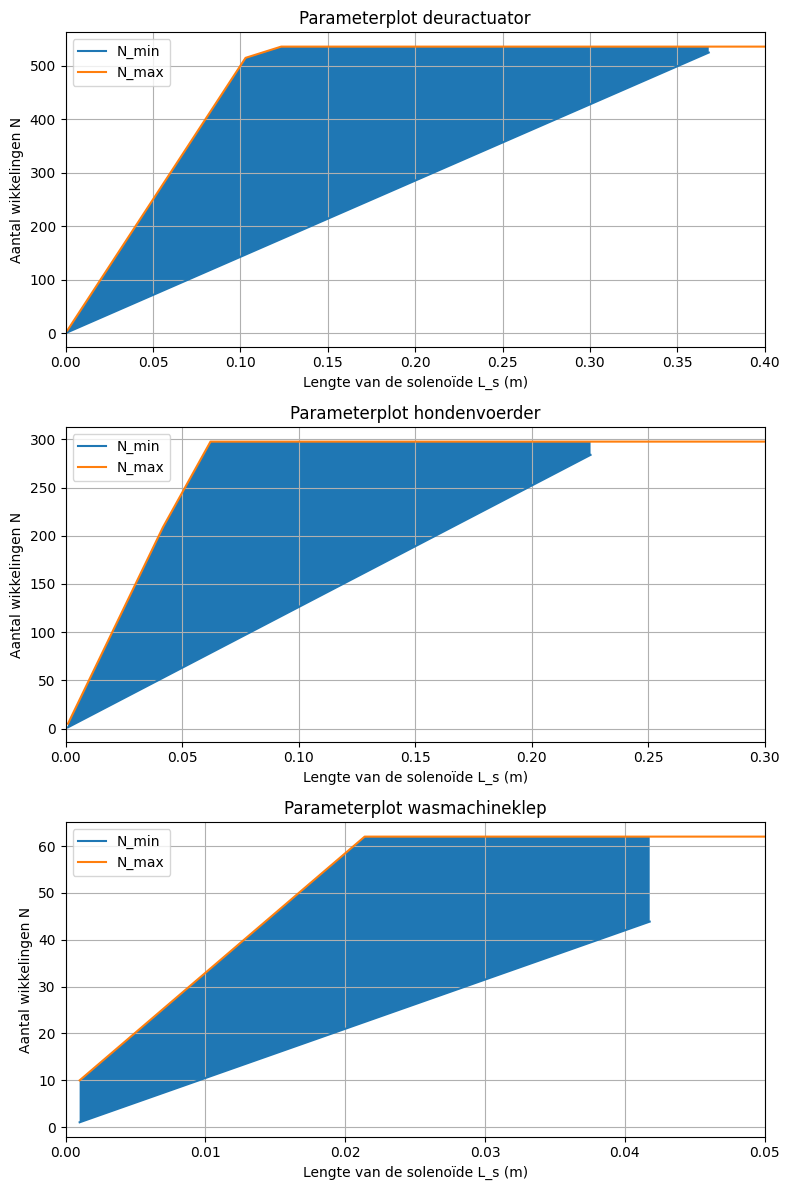

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# deuractuator
axs[0].plot(Ls_waarden, Nmin_deur, label='N_min')
axs[0].plot(Ls_waarden, Nmax_deur, label='N_max')
axs[0].fill_between(
    Ls_waarden,
    Nmin_deur,
    Nmax_deur,
    where=(np.array(Nmin_deur) <= np.array(Nmax_deur)))
axs[0].set_xlim(0,0.4)
axs[0].set_title('Parameterplot deuractuator')
axs[0].set_xlabel('Lengte van de solenoïde L_s (m)')
axs[0].set_ylabel('Aantal wikkelingen N')
axs[0].legend()
axs[0].grid(True)

# hondenvoerder
axs[1].plot(Ls_waarden, Nmin_hond, label='N_min')
axs[1].plot(Ls_waarden, Nmax_hond, label='N_max')
axs[1].fill_between(
    Ls_waarden,
    Nmin_hond,
    Nmax_hond,
    where=(np.array(Nmin_hond) <= np.array(Nmax_hond)))
axs[1].set_xlim(0,0.3)
axs[1].set_title('Parameterplot hondenvoerder')
axs[1].set_xlabel('Lengte van de solenoïde L_s (m)')
axs[1].set_ylabel('Aantal wikkelingen N')
axs[1].legend()
axs[1].grid(True)

# wasmachineklep
axs[2].plot(Ls_waarden, Nmin_was, label='N_min')
axs[2].plot(Ls_waarden, Nmax_was, label='N_max')
axs[2].fill_between(
    Ls_waarden,
    Nmin_was,
    Nmax_was,
    where=(np.array(Nmin_was) <= np.array(Nmax_was)))
axs[2].set_xlim(0,0.050)
axs[2].set_title('Parameterplot wasmachineklep')
axs[2].set_xlabel('Lengte van de solenoïde L_s (m)')
axs[2].set_ylabel('Aantal wikkelingen N')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

*Antwoord*

Bij een parameterplot wordt het gebied weergegeven tussen de gestelde eisen, in dit geval het minimale en maximale aantal wikkelingen als functie van de lengte van de solenoïde. Het ingevulde gebied geeft aan welke combinaties van parameters leiden tot een haalbaar ontwerp van de actuator. We liepen alleen tegen het probleem aan dat met de oorspronkelijke, realistische waarden voor de drie actuatoren er geen overlap bleek te zijn tussen het minimale en maximale aantal wikkelingen, waardoor er geen gevuld gebied in de parameterplots ontstond. Dit betekent dat er met deze parameters geen haalbaar ontwerp mogelijk is.

Pas na het verlagen van de minimale kracht ontstond er wel een zichtbaar parametergebied. De gebruikte kracht is daarom erg klein en dient het vooral om een inzicht te krijgen hoe de parameters van elkaar af zouden kunnen hangen. Voor de parameterplot van de deuractuator is de kracht zelfs met vijf ordes van grootte kleiner geworden. 

Het doel van deze stap is vooral om inzicht te krijgen in het ontwerpproces. Zolang de gekozen parameters binnen het gevulde gebied van de parameterplot liggen, betekent dit dat het ontwerp voldoet aan de gestelde randvoorwaarden binnen de gemaakte aannames.

*1. Deuractuator*

- Lengte van de spoel: $L_s$ = 0.10 $m$
- Straal van de spoel: $r_s$ = 0.010 $m$
- Lengte van de draad: $l_d$ = 7.5 $m$

*2. Hondenvoerklep*

- Lengte van de spoel: $L_s$ = 0.08 $m$
- Straal van de spoel: $r_s$ = 0.010 $m$
- Lengte van de draad: $l_d$ = 15.0 $m$

*3. Wasmachineklep*

- Lengte van de spoel: $L_s$ = 0.03 $m$
- Straal van de spoel: $r_s$ = 0.012 $m$
- Lengte van de draad: $l_d$ = 10.0 $m$

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [10]:
L_draad = 0.1
dl=np.array([0, 0, L_draad/64])
r_field=np.array([0.1, 0, 0])
r_source=np.array([0, 0, 0])
I = 6



def field_current_element(r_field, r_source, dl):
    R = r_field - r_source
    R_norm = np.linalg.norm(R)
    R_hat = R / R_norm

    dH = (I / (4 * np.pi)) * np.cross(dl, R_hat) / (R_norm**2)
    return dH

analytical_answer=(I/4/np.pi)*(L_draad/64)/np.sum((r_field-r_source)**2) # een veld elementje.
print('The analytical answer is ' + str(analytical_answer) + ' A/m in the y-direction')

print('The numerical answer is is ' + str(field_current_element(r_field, r_source, dl)) + ' A/m')

The analytical answer is 0.07460387957432593 A/m in the y-direction
The numerical answer is is [0.         0.07460388 0.        ] A/m


Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

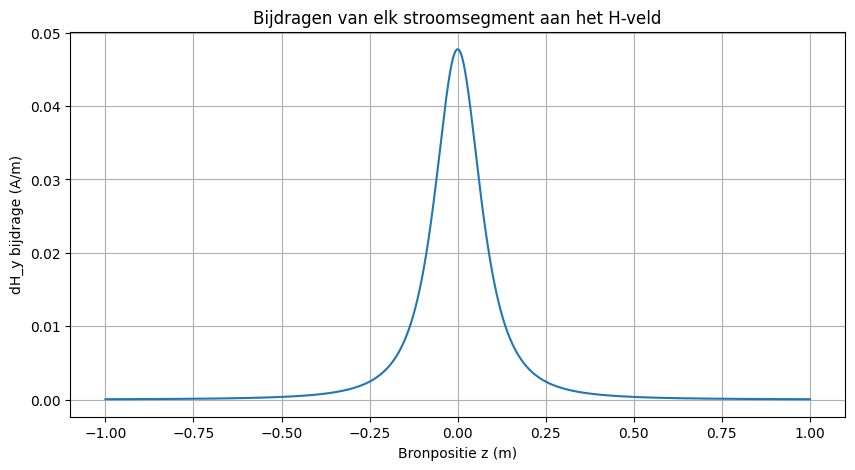

Analytisch H-veld = 9.549296585513721 A/m (y-richting)
Numeriek H-veld   = [0.         9.49720131 0.        ] A/m


In [11]:
# Gegeven waarden
I = 6                      # stroom (A)
L = 2.0                    # totale draadlengte (m)
N = 2000                   # aantal stukjes
dl_length = L / N          # lengte van elk stukje


#arrays met bronposities langs z-a
z_positions = np.linspace(-L/2, L/2, N)
dl = np.array([0, 0, dl_length])


#alle dH bijdragen
dH_list = []
for z in z_positions:
    r_source = np.array([0, 0, z])
    dH = field_current_element(r_field, r_source, dl)
    dH_list.append(dH)

dH_array = np.array(dH_list)


#Plot
plt.figure(figsize=(10,5))
plt.plot(z_positions, dH_array[:,1])
plt.xlabel("Bronpositie z (m)")
plt.ylabel("dH_y bijdrage (A/m)")
plt.title("Bijdragen van elk stroomsegment aan het H-veld")
plt.grid(True)
plt.show()


# H totaal
H_total = np.sum(dH_array, axis=0)


# Analytische oplossing oneindige draad
H_analytical = I / (2 * np.pi * 0.1)

print("Analytisch H-veld =", H_analytical, "A/m (y-richting)")
print("Numeriek H-veld   =", H_total, "A/m")


### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [12]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

Aantal omwentelingen: 159.15
Spoed: 1591.55 omwentelingen per meter


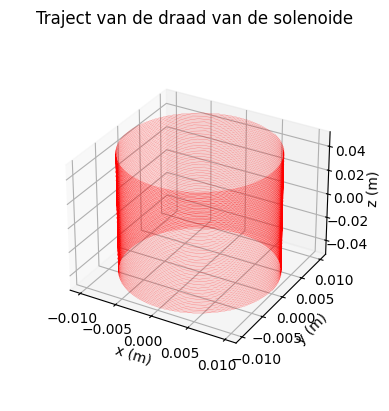

In [13]:
l_draad = 10.0      # totale draadlengte (m)
r_sol   = 0.01      # straal solenoide (m)
L_sol   = 0.10      # lengte solenoide (m)
N       = 5000      # aantal punten voor het traject

# a) aantal omwentelingen
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)
print(f"Aantal omwentelingen: {aantal_omwentelingen:.2f}")

# b) x, y, z coördinaten
x, y, z = parametrisatie(N, r_sol, aantal_omwentelingen, L_sol)

# c) spoed (omwentelingen per meter)
spoed = aantal_omwentelingen / L_sol
print(f"Spoed: {spoed:.2f} omwentelingen per meter")

# Enkele plots
ax = plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.1)
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()


Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [14]:
I = 2.0          # stroom (A)
l_draad = 10.0   # totale draadlengte (m)
r_sol   = 0.01   # straal solenoide (m)
L_sol   = 0.10   # lengte solenoide (m)

# aantal omwentelingen en spoed
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)
n = aantal_omwentelingen / L_sol   # spoed (omwentelingen per meter)

# analytisch veld in het midden
H_analytical = n * I
print(f"Analytisch H-veld in het midden: {H_analytical:.4f} A/m (z-richting)")

#parametrisatie solenoide 
def parametrisatie(N, r_sol, aantal_omwentelingen, L_sol):
    t = np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen * t)
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen * t)
    z = L_sol * t - L_sol/2
    return x, y, z

#Biot–Savart 1 element
def field_current_element(r_field, r_source, dl):
    R = r_field - r_source
    R_norm = np.linalg.norm(R)
    R_hat = R / R_norm
    dH = (I / (4 * np.pi)) * np.cross(dl, R_hat) / (R_norm**2)
    return dH

#numerieke integratie verschillende N
r_field = np.array([0.0, 0.0, 0.0])
N_list = [200, 500, 1000, 2000, 5000]

for N in N_list:
    x, y, z = parametrisatie(N, r_sol, aantal_omwentelingen, L_sol)
    r_points = np.vstack((x, y, z)).T          # (N, 3)
    dl_vecs = np.diff(r_points, axis=0)        # (N-1, 3)
    r_sources = r_points[:-1]                  # bronposities per segment

    dH_list = []
    for rs, dl in zip(r_sources, dl_vecs):
        dH_list.append(field_current_element(r_field, rs, dl))

    H_total = np.sum(dH_list, axis=0)

    print(f"N = {N:5d}  ->  H_num = {H_total} A/m")


Analytisch H-veld in het midden: 3183.0989 A/m (z-richting)
N =   200  ->  H_num = [-5.02070312e-01  9.30850266e-01 -5.91007123e+02] A/m
N =   500  ->  H_num = [-4.99490223e-01  9.36871538e-01  1.41364073e+03] A/m
N =  1000  ->  H_num = [-4.98179088e-01  9.37858792e-01  2.62552951e+03] A/m
N =  2000  ->  H_num = [-4.97494430e-01  9.38289101e-01  2.99272076e+03] A/m
N =  5000  ->  H_num = [-4.97075180e-01  9.38529655e-01  3.10050994e+03] A/m


### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

Ifield = 24

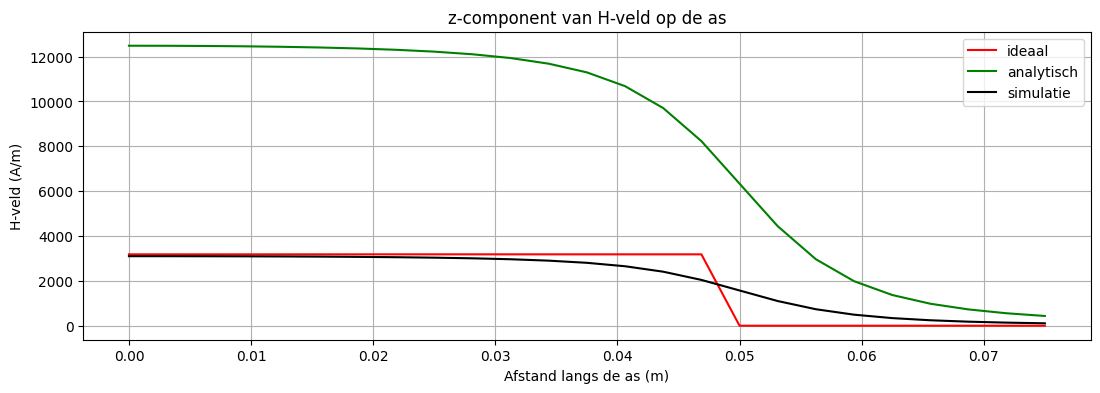

In [15]:

r_sources = np.vstack((x, y, z)).T
dl_vecs = np.diff(r_sources, axis=0)


# Veldpunten op de as

n_ax = 25
z_ax = np.linspace(0, 1.5*L_sol/2, n_ax)
H_ax = np.zeros((n_ax, 1))

for i_field in range(n_ax):
    print(f"\rIfield = {i_field}", end="")
    r_field = np.array([0.0, 0.0, z_ax[i_field]])
    Hsimulated = np.array([0.0, 0.0, 0.0])

    for rs, dl in zip(r_sources[:-1], dl_vecs):
        Hsimulated += field_current_element(r_field, rs, dl)

    H_ax[i_field, 0] = Hsimulated[2]


# Ideaal veld
H_veld_ideaal = (n * I) * (z_ax < L_sol/2)


# Analytisch eindige solenoide
H_veld_analytisch = (aantal_omwentelingen * I / (L_sol/2)) * (
    (L_sol/2 - z_ax)/np.sqrt((z_ax - L_sol/2)**2 + r_sol**2) +
    (L_sol/2 + z_ax)/np.sqrt((z_ax + L_sol/2)**2 + r_sol**2)
)

# Plot

plt.figure(figsize=[13,4])
plt.title('z-component van H-veld op de as')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.grid(True)
plt.show()


We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

(Text(0.5, 0, 'Afstand van plunjer in solenoide (m)'),
 Text(0, 0.5, 'Energie (J)'),
 None)

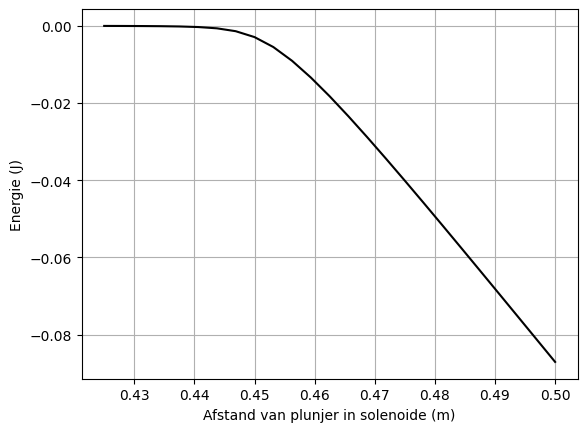

In [16]:
# aannames
mu_0 = 4 * np.pi * 1e-7      # H/m
mu_r = 1000                  # ijzer


# integrate the field up to point z_p
Wz=-0.5*np.pi*r_sol**2*np.cumsum(np.flipud(H_ax)*mu_r*mu_0*np.flipud(H_ax))*(z_ax[1] - z_ax[0])

plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Energie (J)'), plt.grid()

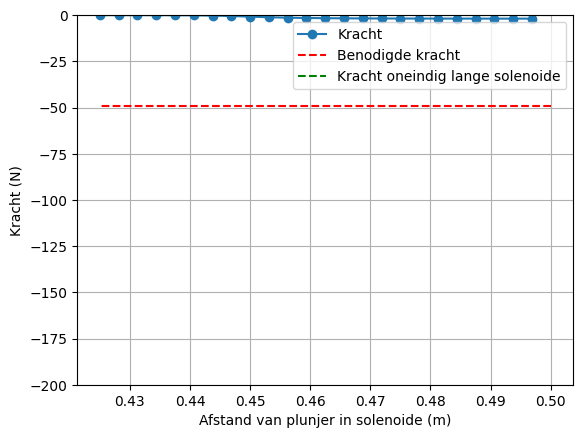

In [17]:
force_analytical = -mu_0*mu_r*np.pi*r_sol**2*aantal_omwentelingen**2*I**2/(2*L_s**2) # Kracht uitrekenen numeriek
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_s/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht')
plt.plot(L_s/2 - z_ax, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_s/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-200, 0])
plt.show()

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


*Plaats hier jullie evaluatie of de deur actuator aan de minimale kracht eis voldoet*

*Evaluatie*

In deze ontwerpopdracht waren de belangrijkste criteria voor de deuractuator dat het een kracht van 40 $N$ moet kunnen leveren, dat het gebruik maakt van een 9 $V$ batterij als stroombron en een straal heeft van 0,01 $m$. 

Op basis van de berekeningen en parameterplots is er onderzocht of er combinaties van spoellengte, straal en draadlengte bestaan die aan deze eisen voldoen. Hieruit bleek dat er bij de oorspronkelijke, realistische kracht van 40 $N$ geen overlap is tussen het minimale en maximale aantal windingen. Er is geen ontwerp die aan deze eisen kan voldoen. Om toch inzicht te krijgen in het ontwerpproces hebben we de minimale kracht sterk verlaagd (met ongeveer vijf ordes van grootte). Hierdoor ontstond er wel een haalbaar parametergebied en konden we ontwerpkeuzes maken voor de spoel. Deze keuzes liggen binnen het gesimuleerde parametergebied en voldoen dan wel aan de voorwaarden.

Maar dat neemt niet weg dat de resultaten ongeldig zijn, gezien ze gebasseerd zijn op een sterk verlaagde minimale kracht. Het ontwerp voldoet dus alleen aan de criteria met een lage kracht, maar niet aan de realistische eisen van de deuractuator.

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

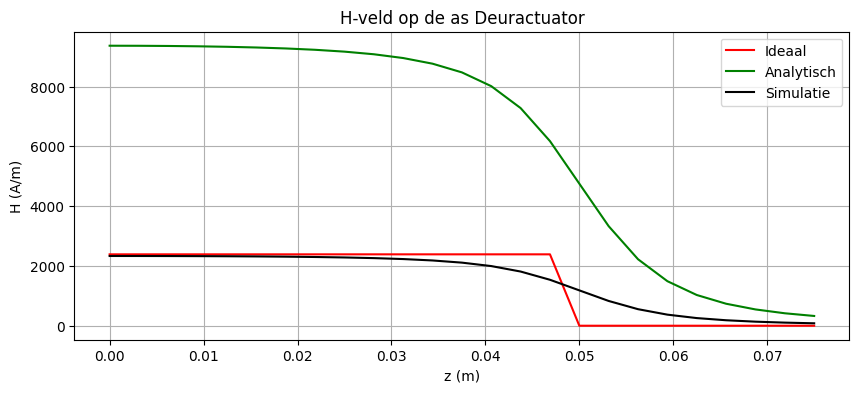

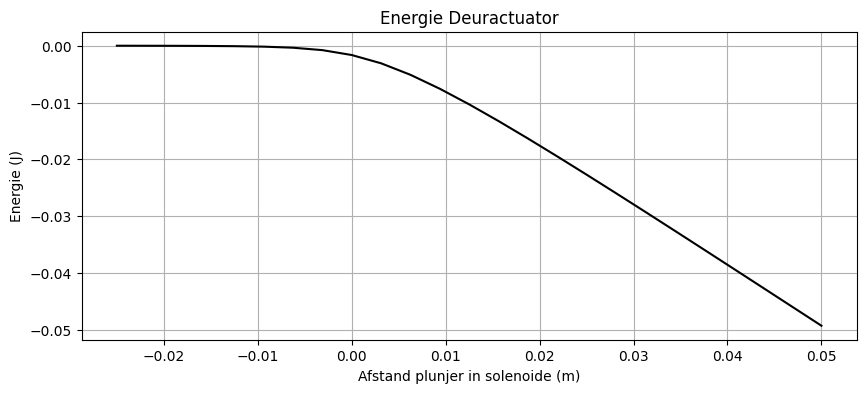

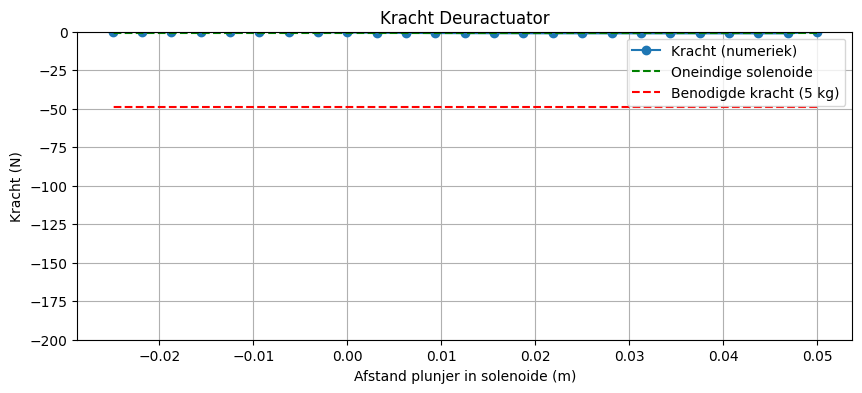

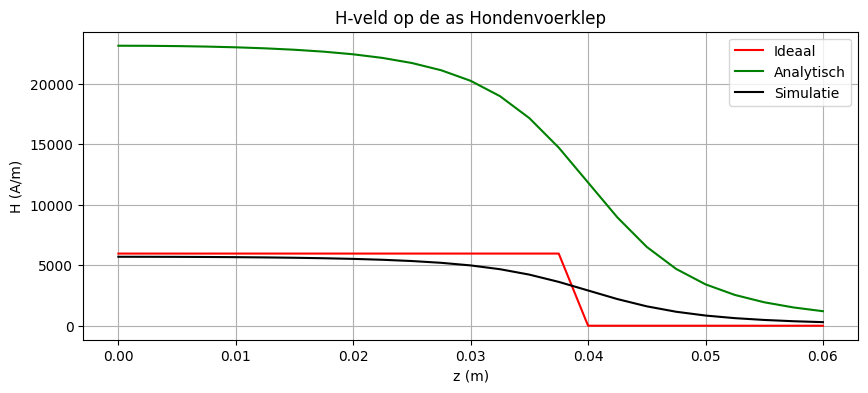

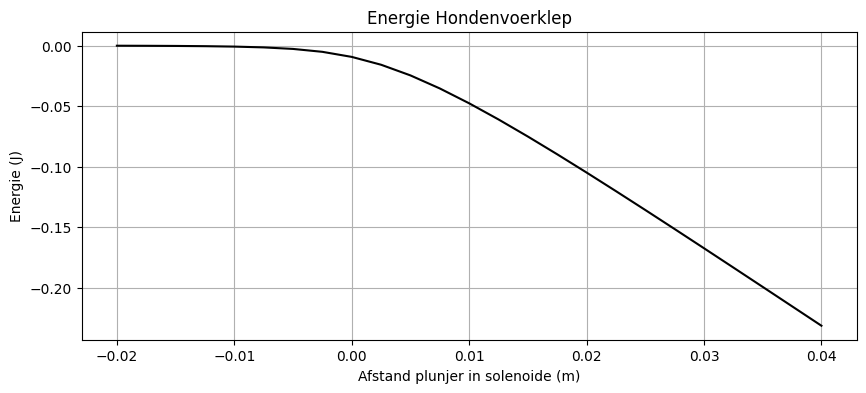

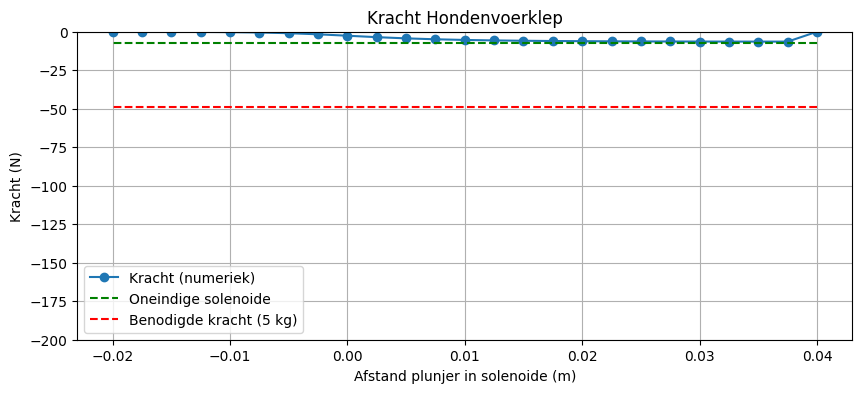

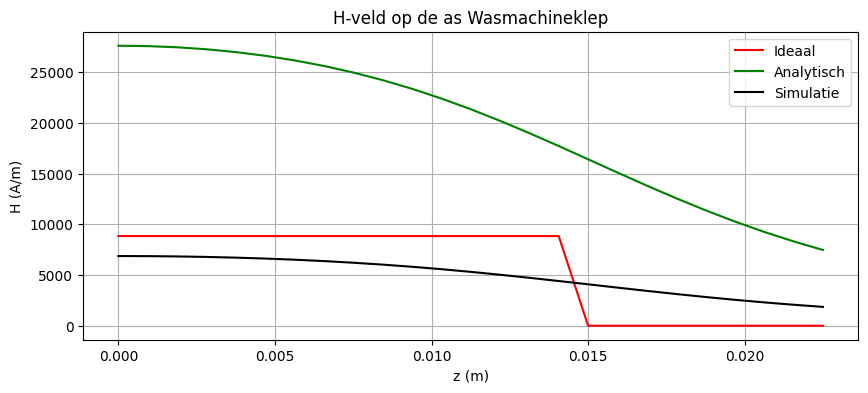

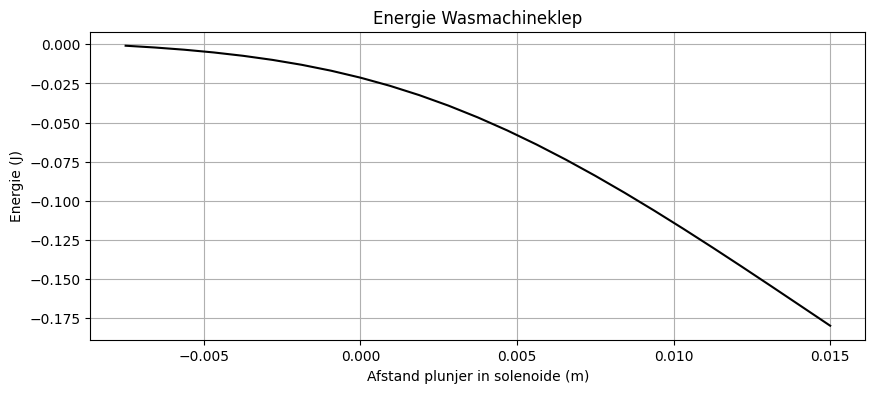

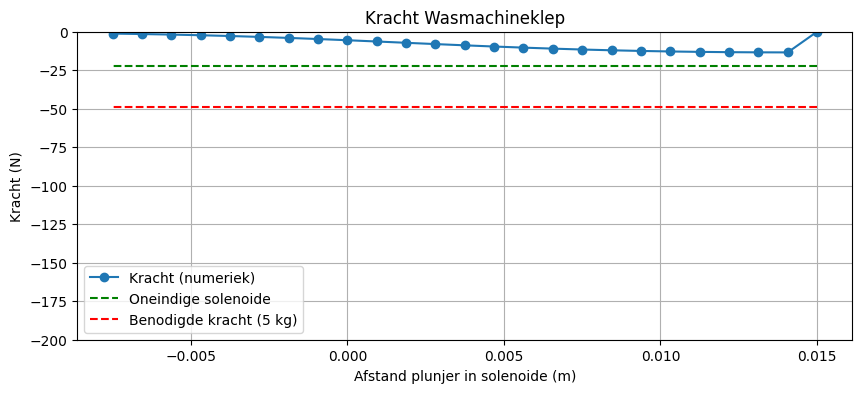

In [18]:


mu_0 = 4 * np.pi * 1e-7
mu_r = 1000
I = 2.0


# actuatorparameters opdracht 10

actuators = {
    "Deuractuator":      {"L_s": 0.10, "r_s": 0.010, "l_d": 7.5},
    "Hondenvoerklep":    {"L_s": 0.08, "r_s": 0.010, "l_d": 15.0},
    "Wasmachineklep":    {"L_s": 0.03, "r_s": 0.012, "l_d": 10.0},
}


for naam, params in actuators.items():

    L_s = params["L_s"]
    r_s = params["r_s"]
    l_d = params["l_d"]

    # aantal windingen en spoed
    aantal_omwentelingen = l_d / (2 * np.pi * r_s)
    n = aantal_omwentelingen / L_s


    # OPDRACHT 15: H-veld op de as
    N = 5000
    x_s, y_s, z_s = parametrisatie(N, r_s, aantal_omwentelingen, L_s)
    r_sources = np.vstack((x_s, y_s, z_s)).T
    dl_vecs = np.diff(r_sources, axis=0)

    n_ax = 25
    z_ax = np.linspace(0, 1.5 * L_s / 2, n_ax)
    H_ax = np.zeros((n_ax, 1))

    for i_field in range(n_ax):
        r_field = np.array([0.0, 0.0, z_ax[i_field]])
        Hsim = np.array([0.0, 0.0, 0.0])
        for rs, dl in zip(r_sources[:-1], dl_vecs):
            Hsim += field_current_element(r_field, rs, dl)
        H_ax[i_field, 0] = Hsim[2]

    # analytisch eindige solenoïde
    H_analytisch = (aantal_omwentelingen * I / (L_s/2)) * (
        (L_s/2 - z_ax)/np.sqrt((z_ax - L_s/2)**2 + r_s**2) +
        (L_s/2 + z_ax)/np.sqrt((z_ax + L_s/2)**2 + r_s**2)
    )

    # ideaal veld
    H_ideaal = (n * I) * (z_ax < L_s/2)

    # plot H-veld
    plt.figure(figsize=(10,4))
    plt.title(f"H-veld op de as {naam}")
    plt.plot(z_ax, H_ideaal, '-r', label='Ideaal')
    plt.plot(z_ax, H_analytisch, '-g', label='Analytisch')
    plt.plot(z_ax, H_ax, '-k', label='Simulatie')
    plt.xlabel("z (m)")
    plt.ylabel("H (A/m)")
    plt.grid()
    plt.legend()


    # OPDRACHT 16: Energie en kracht
    dz = z_ax[1] - z_ax[0]

    Wz = -0.5 * np.pi * r_s**2 * np.cumsum(
        np.flipud(H_ax[:,0]) * mu_r * mu_0 * np.flipud(H_ax[:,0])
    ) * dz

    plt.figure(figsize=(10,4))
    plt.title(f"Energie {naam}")
    plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
    plt.xlabel("Afstand plunjer in solenoide (m)")
    plt.ylabel("Energie (J)")
    plt.grid()

    # kracht numeriek
    force_numerical = np.diff(Wz, append=[Wz[-1]]) / dz

    # kracht analytisch oneindige solenoïde
    force_analytical = -(mu_0 * mu_r * np.pi * r_s**2 *
                         aantal_omwentelingen**2 * I**2) / (2 * L_s**2)

    plt.figure(figsize=(10,4))
    plt.title(f"Kracht {naam}")
    plt.plot(L_s/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht (numeriek)')
    plt.plot(L_s/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Oneindige solenoide')
    plt.plot(L_s/2 - z_ax, -5*9.8*np.ones(n_ax), '--r', label='Benodigde kracht (5 kg)')
    plt.xlabel("Afstand plunjer in solenoide (m)")
    plt.ylabel("Kracht (N)")
    plt.grid()
    plt.legend()
    plt.ylim([-200, 0])

plt.show()

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

*Antwoord vraag 19*

Met de simulaties uit opdrachten 15 en 16 toegepast op onze ontwerpen, hebben we inzicht gekregen op het gedrag van iedere actuator. Hiermee kunnen we beoordelen of de actuator in staat is om de benodigde kracht te leveren en hoe deze kracht zich gedraagt tijdens de beweging van plunjer. Alleen zijn deze simulaties gebasseerd op perfecte omstandigheden, bijvoorbeeld wrijving en thermische effecten zijn niet meegenomen. Daarnaast hebben we voor alle drie de toepassingen (deuractuator, hondenvoerklep en wasmachineklep) de minimale kracht sterk moeten verlagen om überhaupt een haalbaar parametergebied te verkrijgen.

Daarom hebben we nog niet genoeg informatie om met zekerheid te concluderen dat het ontwerp in de praktijk voldoet.

Om meer inzicht te krijgen in of ons ontwerp zou kunnen functioneren in het echt en aan de opgestelde criteria voldoet, kunnen we de simulaties vergelijken met de realiteit. We testen de criteria op basis van een simpel experiment waar een prototype van de solenoïde wordt gebruikt. Dan kan bij een bekende stroom de kracht op de plunjer gemeten worden met een krachtmeter. Door deze metingen uit te voeren voor verschillende posities van de plunjer, kan de kracht als functie van de positie worden bepaald.

Door deze experimentele resultaten te vergelijken met de simulaties kan worden gecontroleerd of het model een realistische beschrijving geeft van de actuator. Op basis hiervan kan beter worden beoordeeld of het ontwerp aan de gestelde criteria voldoet en of aanpassingen nodig zijn voor een werkende actuator in de praktijk.Edit deze cel met jullie antwoorden op vraag 19.

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.